In [2]:
import os
import cv2
import numpy as np
import shutil
import random

# Set fixed random seeds for reproducibility
random.seed(42)
np.random.seed(42)


def random_augment(img, transform_counts):
    """
    Apply a random augmentation from:
    - none (do nothing)
    - grayscale
    - reddish tint
    - greenish tint
    - blueish tint
    - brighten
    - darken
    - blur (Gaussian blur)

    The probabilities are weighted so that "none" and "gray" are more likely.
    Here, 20% of the images will get blurred.
    """
    # Original weights were: [0.3, 0.35, 0.05, 0.05, 0.05, 0.1, 0.1] summing to 1.
    # To include "blur" at 20%, we scale the others by 0.8:
    # none: 0.3 * 0.8 = 0.24, gray: 0.35 * 0.8 = 0.28,
    # red/green/blue: 0.05 * 0.8 = 0.04 each,
    # bright_up: 0.1 * 0.8 = 0.08, bright_down: 0.1 * 0.8 = 0.08.
    # Then add "blur" with weight 0.2.
    transforms = ["none", "gray", "red", "green", "blue", "bright_up", "bright_down", "blur"]
    # weights = [0.25, 0.28, 0.05, 0.05, 0.05, 0.08, 0.08, 0.16]
    weights = [0.44, 0.20, 0.05, 0.05, 0.05, 0.08, 0.08, 0.05]
    # weights = [0.05, 0.2, 0.2, 0.2, 0.2, 0.05, 0.05, 0.05]

    transform = random.choices(transforms, weights=weights, k=1)[0]
    transform_counts[transform] += 1  # increment counter for chosen transform

    if transform == "none":
        # Do nothing
        return img

    elif transform == "gray":
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Convert back to 3-channel so shape remains (H, W, 3)
        img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    elif transform == "red":
        # Increase red channel for a reddish tint
        b, g, r = cv2.split(img)
        r = cv2.add(r, 50)  # shift red channel
        r = np.clip(r, 0, 255).astype(np.uint8)
        img = cv2.merge([b, g, r])

    elif transform == "green":
        # Increase green channel for a greenish tint
        b, g, r = cv2.split(img)
        g = cv2.add(g, 50)
        g = np.clip(g, 0, 255).astype(np.uint8)
        img = cv2.merge([b, g, r])

    elif transform == "blue":
        # Increase blue channel for a blueish tint
        b, g, r = cv2.split(img)
        b = cv2.add(b, 50)
        b = np.clip(b, 0, 255).astype(np.uint8)
        img = cv2.merge([b, g, r])

    elif transform == "bright_up":
        # Increase brightness and contrast slightly
        img = cv2.convertScaleAbs(img, alpha=1.2, beta=20)

    elif transform == "bright_down":
        # Decrease brightness and contrast slightly
        img = cv2.convertScaleAbs(img, alpha=0.8, beta=-20)

    elif transform == "blur":
        # Apply a Gaussian blur with a 5x5 kernel
        img = cv2.GaussianBlur(img, (5, 5), 0)

    return img


def create_augmented_dataset(input_dir, output_dir):
    """
    Copy the dataset structure from input_dir to output_dir and apply
    color/brightness (and blur) augmentations to each image. Labels are copied unchanged.

    Expected structure in input_dir:
    input_dir/
    ├── train
    │   ├── images
    │   └── labels
    ├── valid
    │   ├── images
    │   └── labels
    └── test
        ├── images
        └── labels

    Resulting structure in output_dir is similar.
    """
    subsets = ["train", "valid", "test"]
    
    # Counters for subsets
    subset_counts = {"train": 0, "valid": 0, "test": 0}

    # Counters for each transform
    transform_counts = {
        "none": 0,
        "gray": 0,
        "red": 0,
        "green": 0,
        "blue": 0,
        "bright_up": 0,
        "bright_down": 0,
        "blur": 0
    }

    for subset in subsets:
        images_in = os.path.join(input_dir, subset, "images")
        labels_in = os.path.join(input_dir, subset, "labels")

        images_out = os.path.join(output_dir, subset, "images")
        labels_out = os.path.join(output_dir, subset, "labels")

        os.makedirs(images_out, exist_ok=True)
        os.makedirs(labels_out, exist_ok=True)

        # Process each image in the subset
        if not os.path.isdir(images_in):
            print(f"Warning: no images folder found for '{subset}' at {images_in}")
            continue

        for img_file in os.listdir(images_in):
            # Only process image files
            if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            # Read the original image
            img_path = os.path.join(images_in, img_file)
            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: failed to load image {img_path}")
                continue

            # Apply a random augmentation
            aug_img = random_augment(img, transform_counts)

            # Save augmented image
            out_img_path = os.path.join(images_out, img_file)
            cv2.imwrite(out_img_path, aug_img)

            # Copy the corresponding label file (if it exists)
            label_file = os.path.splitext(img_file)[0] + ".txt"
            label_src = os.path.join(labels_in, label_file)
            label_dst = os.path.join(labels_out, label_file)
            if os.path.exists(label_src):
                shutil.copy(label_src, label_dst)

            subset_counts[subset] += 1

    # Print summary
    print("\n=== Augmentation Summary ===")
    print("Number of images processed for each subset:")
    for s in subsets:
        print(f"  {s}: {subset_counts[s]}")

    print("\nNumber of images for each transformation:")
    for t in transform_counts:
        print(f"  {t}: {transform_counts[t]}")

if __name__ == "__main__":
    # Example usage:
    # Suppose your original dataset is in 'dataset' with subfolders train/valid/test
    input_dataset = "dataset"

    # The new dataset with augmentations will be stored in 'new_dataset'
    output_dataset = "new_dataset"

    create_augmented_dataset(input_dataset, output_dataset)
    print("\nAugmented dataset created successfully!")



=== Augmentation Summary ===
Number of images processed for each subset:
  train: 1033
  valid: 341
  test: 0

Number of images for each transformation:
  none: 589
  gray: 281
  red: 74
  green: 63
  blue: 73
  bright_up: 129
  bright_down: 98
  blur: 67

Augmented dataset created successfully!


# YOLO v8

In [10]:
import os
# os.environ["TORCHDYNAMO_DISABLE"] = "1"
import torch
from ultralytics import YOLO




In [11]:
model = YOLO("yolo_models/yolov8n.pt")  # or "yolo_models/yolov8n.pt"
model.train(
    data="dataset.yaml",  # path to the YAML file above
    epochs=80,
    patience=20,
    imgsz=416,
    batch=16,
    half=False,  # disable FP16 if desired

    # Built-in augmentations:
    # hsv_h=0.015,        # Adjust hue
    # hsv_s=0.7,          # Adjust saturation
    # hsv_v=0.4,          # Adjust value/brightness
    fliplr=0.5,         # 50% chance to flip images horizontally
    flipud=0.5,         # 0% chance to flip vertically
    scale=0.7,          # Random scale
    translate=0.3,      # Random translation
    mosaic=0.95,         # Use Mosaic augmentation
    mixup=0.1,           # Use MixUp augmentation
    tracker='bytetrack.yaml'
)

New https://pypi.org/project/ultralytics/8.3.100 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.82  Python-3.12.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo_models/yolov8n.pt, data=dataset.yaml, epochs=80, time=None, patience=20, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train29, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, s

train: Scanning C:\Machine Learning\Rat-Tracking-using-YOLO\new_dataset\train\labels... 1400 images, 378 backgrounds, 1 corrupt: 100%|██████████| 1402/1402 [00:01<00:

train: WARNING  C:\Machine Learning\Rat-Tracking-using-YOLO\new_dataset\train\images\random_youtube_video_frame_001802.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0972]


train: New cache created: C:\Machine Learning\Rat-Tracking-using-YOLO\new_dataset\train\labels.cache


val: Scanning C:\Machine Learning\Rat-Tracking-using-YOLO\new_dataset\valid\labels... 600 images, 162 backgrounds, 0 corrupt: 100%|██████████| 600/600 [00:04<00:00, 1

...

                   all        600        697       0.92      0.788      0.856      0.478



80 epochs completed in 0.439 hours.
Optimizer stripped from c:\Machine Learning\Rat-Tracking-using-YOLO\runs\detect\train29\weights\last.pt, 6.2MB
Optimizer stripped from c:\Machine Learning\Rat-Tracking-using-YOLO\runs\detect\train29\weights\best.pt, 6.2MB

Validating c:\Machine Learning\Rat-Tracking-using-YOLO\runs\detect\train29\weights\best.pt...
Ultralytics 8.3.82  Python-3.12.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:04<00:00,  4.31it/s]


                   all        600        697      0.909      0.791      0.853       0.48
WARNING  ConfusionMatrix plot failure: No module named 'seaborn'
WARNING  ConfusionMatrix plot failure: No module named 'seaborn'
Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to c:\Machine Learning\Rat-Tracking-using-YOLO\runs\detect\train29


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000019515592870>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

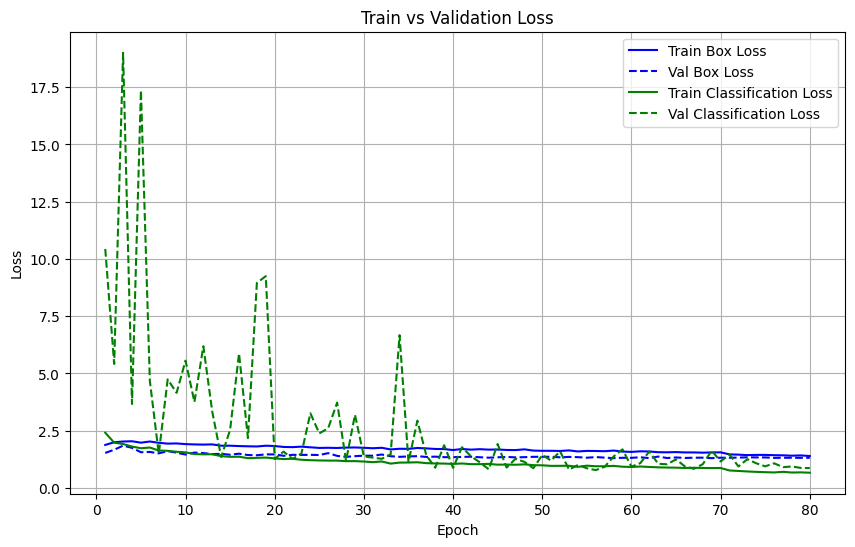

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


# Path to the results CSV
results_path = "runs/detect/train29/results.csv"

# Read the results CSV
results = pd.read_csv(results_path)

# Plot train vs test losses
plt.figure(figsize=(10, 6))

# Box loss
plt.plot(results["epoch"], results["train/box_loss"], label="Train Box Loss", color="blue")
plt.plot(results["epoch"], results["val/box_loss"], label="Val Box Loss", color="blue", linestyle="dashed")

# Objectness loss
# plt.plot(results["epoch"], results["train/obj_loss"], label="Train Objectness Loss", color="orange")
# plt.plot(results["epoch"], results["val/obj_loss"], label="Val Objectness Loss", color="orange", linestyle="dashed")

# Classification loss
plt.plot(results["epoch"], results["train/cls_loss"], label="Train Classification Loss", color="green")
plt.plot(results["epoch"], results["val/cls_loss"], label="Val Classification Loss", color="green", linestyle="dashed")

# Add labels, legend, and grid
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
import cv2
import time
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO
%matplotlib inline

# Load trained YOLOv8 model
model = YOLO("runs/detect/train29/weights/best.pt")  # Adjust model path if needed

# Define test image directory
test_images_dir = "dataset/test/images/"

# Get list of test images
image_paths = glob(test_images_dir + "*.jpg")  # Adjust extension if needed

# Run inference on multiple images and record inference time
for image_path in image_paths[25:]:  # Adjust the number of images to display
    # Load and preprocess image
    # image_path = '/content/Screenshot 2025-02-06 170103.png'
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

    # Run inference and measure time
    start_time = time.time()
    results = model(image)
    end_time = time.time()
    inference_time = end_time - start_time

    # Access detection results and filter by confidence
    detection_result = results[0]
    boxes = detection_result.boxes  # Get bounding boxes

    # Filter boxes with confidence > 0.7
    filtered_boxes = [box for box in boxes if box.conf.item() > 0.01]

    # Select the best bounding box (highest confidence)
    best_box = max(filtered_boxes, key=lambda b: b.conf.item(), default=None)

    # Plot the image
    plt.figure(figsize=(8, 6))
    plt.imshow(image)

    if filtered_boxes:
        for box in filtered_boxes:
            bbox = box.xyxy[0].cpu().numpy()  # Bounding box coordinates (x_min, y_min, x_max, y_max)
            conf = box.conf.item()  # Confidence score

            # Plot each bounding box
            plt.gca().add_patch(
                plt.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                              edgecolor="green", fill=False, linewidth=2, label=f"Conf: {conf:.2f}")
            )

        plt.title(f"Inference Time: {inference_time:.3f} sec | {len(filtered_boxes)} Detections")
        plt.legend()
    else:
        plt.title(f"Inference Time: {inference_time:.3f} sec | No Detections > 0.7")

    plt.axis("off")  # Hide axes
    plt.show()

    print(f"Processed: {image_path} | Inference Time: {inference_time:.3f} sec")

    if best_box:  # Check if best_box is found
        bbox = best_box.xyxy[0].cpu().numpy()
        conf = best_box.conf.item()
        print(f"✅ Best Detection: {bbox} | Confidence: {conf:.2f}")
    else:
        print(f"❌ No detections with confidence > 0.7 for {image_path}")


In [ ]:
model.export(format="onnx", opset=12, simplify=True, dynamic=False, imgsz=416)

Ultralytics 8.3.82  Python-3.12.9 torch-2.6.0+cu118 CPU (Intel Core(TM) i5-4690 3.50GHz)

PyTorch: starting from 'runs\detect\train10\weights\best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 5, 3549) (5.9 MB)

ONNX: starting export with onnx 1.17.0 opset 12...
ONNX: slimming with onnxslim 0.1.48...
ONNX: export success  2.2s, saved as 'runs\detect\train10\weights\best.onnx' (11.6 MB)

Export complete (2.7s)
Results saved to C:\Machine Learning\Rat-Tracking-using-YOLO\runs\detect\train10\weights
Predict:         yolo predict task=detect model=runs\detect\train10\weights\best.onnx imgsz=416  
Validate:        yolo val task=detect model=runs\detect\train10\weights\best.onnx imgsz=416 data=dataset.yaml  
Visualize:       https://netron.app


'runs\\detect\\train10\\weights\\best.onnx'

# ✅ Run on CPU & Single Core

In [22]:
import cv2
import time
import torch
from ultralytics import YOLO
import os

# Force YOLO to run on CPU only and limit to 1 core
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Disable GPU
# torch.set_num_threads(1)  # Limit PyTorch to 1 CPU core

# Load trained YOLOv8 model (force CPU usage)
model = YOLO("runs/detect/train29/weights/best.pt")  # Adjust model path if needed


# Path to input video
input_video_path = "Video/3_mice.mp4"
input_video_path = "Video/brown_rats.mp4"
input_video_path = "Video/TestFile_video.mp4"
input_video_path = "Video/desktop.avi"

# Open the video file
cap = cv2.VideoCapture(input_video_path)

# Track time and limit processing to 1 minute (60 seconds)
start_time_global = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # Exit if no frame is returned

    # Convert BGR frame (OpenCV default) to RGB for YOLO
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Run YOLO inference and measure time (on CPU)
    start_time = time.time()
    results = model(rgb_frame, device="cuda")  # Ensure YOLO runs on CPU
    end_time = time.time()
    inference_time = end_time - start_time

    # Access detection results and filter boxes with confidence > 0.7
    detection_result = results[0]
    boxes = detection_result.boxes  # Get bounding boxes
    filtered_boxes = [box for box in boxes if box.conf.item() > 0.2]

    # Draw bounding boxes on the frame
    for box in filtered_boxes:
        bbox = box.xyxy[0].cpu().numpy()  # Bounding box coordinates (x_min, y_min, x_max, y_max)
        conf = box.conf.item()  # Confidence score

        x_min, y_min, x_max, y_max = map(int, bbox)
        cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Draw green box
        cv2.putText(frame, f"Conf: {conf:.2f}", (x_min, y_min - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    # Display inference time on the frame
    cv2.putText(frame, f"Inference Time: {inference_time:.3f} sec", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    # Show the processed frame using imshow
    cv2.imshow("YOLO Inference", frame)

    # Wait for 1 ms and break if 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("Exiting display loop by user command.")
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

print("Video processing complete. Display closed.")



0: 320x416 (no detections), 15.5ms
Speed: 2.4ms preprocess, 15.5ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 (no detections), 11.3ms
Speed: 3.8ms preprocess, 11.3ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 (no detections), 16.8ms
Speed: 2.0ms preprocess, 16.8ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 (no detections), 12.0ms
Speed: 2.0ms preprocess, 12.0ms inference, 2.0ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 (no detections), 22.8ms
Speed: 2.0ms preprocess, 22.8ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 (no detections), 19.1ms
Speed: 1.9ms preprocess, 19.1ms inference, 1.8ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 (no detections), 13.0ms
Speed: 2.1ms preprocess, 13.0ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 (no detections), 16.3ms
Speed: 3.0ms preprocess, 16.3ms i

# Track

In [7]:
from collections import defaultdict
import cv2
import time
import torch
import numpy as np
import os
from ultralytics import YOLO

# (Optional) Force YOLO to run on CPU only:
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# torch.set_num_threads(1)

# Load the YOLOv8 model
model = YOLO("runs/detect/train27/weights/best.pt")  # Adjust model path if needed

# Path to input video
input_video_path = "Video/3_mice.mp4"

# Open the video file
cap = cv2.VideoCapture(input_video_path)

# Global start time
start_time_global = time.time()

# Dictionary to store track history: track_id -> list of center points
track_history = defaultdict(list)

tracker_args = {
    'max_age': 30,         # Maximum number of frames to keep a track without detection
    'min_hits': 3,         # Minimum number of detections before a track is confirmed
    'iou_threshold': 0.5   # IoU threshold for associating detections to tracks
    #     track_thresh = 0.2        # Minimum detection confidence for tracking
    # track_buffer = 100         # Maximum frames to keep a lost track
    # match_thresh = 0.9        # Threshold for matching (e.g., IoU)
    # mot20 = False             # MOT20-specific settings flag
    # track_low_thresh = 0.1    # Low threshold for detections (second association)
    # track_high_thresh = 0.2   # High threshold for detections (first association)
    # new_track_thresh = 0.0   # Threshold to initialize a new track
    # fuse_score = False        # Whether to fuse detection score
}

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # End of video or cannot read frame

    # Run YOLO tracking on the frame (persisting tracks between frames)
    start_infer = time.time()
    results = model.track(
        frame,
        persist=True,
        # Uncomment and set a tracker config file if desired:
        tracker='bytetrack.yaml',
    )

    end_infer = time.time()
    inference_time = end_infer - start_infer

    detection_result = results[0]
    # Check if detections exist
    if len(detection_result.boxes) == 0 or detection_result.boxes.id is None:
        annotated_frame = frame.copy()
    else:
        # Get the confidence scores and track IDs
        conf_all = detection_result.boxes.conf.cpu()  # tensor of scores
        track_ids_all = detection_result.boxes.id.int().cpu().tolist()
        
        # Convert the scores to a NumPy array and sort them in descending order
        conf_np = conf_all.numpy()
        sorted_indices = np.argsort(conf_np)[::-1]
        
        # Ensure we don't request more indices than available
        top_n = min(3, len(sorted_indices))
        top_indices = sorted_indices[:top_n]
        print("Top indices:", top_indices)
        
        # Get all detections in xywh format from the current detection result
        boxes_xywh_all_np = detection_result.boxes.xywh.cpu().numpy()
        
        # Manually annotate the frame using a copy of the original frame
        annotated_frame = frame.copy()
        
        # Draw only the top 3 detections
        for idx in top_indices:
            box = boxes_xywh_all_np[idx]
            # Convert from (cx, cy, w, h) to (x1, y1, x2, y2)
            cx, cy, w, h = box
            x1 = int(cx - w / 2)
            y1 = int(cy - h / 2)
            x2 = int(cx + w / 2)
            y2 = int(cy + h / 2)
            
            # Draw the rectangle
            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Get the corresponding track ID and detection score
            track_id = track_ids_all[idx]
            score = conf_np[idx]
            
            # Compose the label text
            label_text = f"ID: {track_id} Score: {score:.2f}"
            # Display the label above the bounding box
            cv2.putText(annotated_frame, label_text, (x1, max(y1 - 10, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            # Update track history and draw polylines for each top detection
            track_history[track_id].append((cx, cy))
            if len(track_history[track_id]) > 30:
                track_history[track_id].pop(0)
            pts = np.array(track_history[track_id], dtype=np.int32).reshape(-1, 1, 2)
            cv2.polylines(annotated_frame, [pts], isClosed=False, color=(230, 230, 230), thickness=2)

    # Overlay inference time
    cv2.putText(annotated_frame, f"Inference Time: {inference_time:.3f} sec", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    # Display the annotated frame
    cv2.imshow("YOLO Tracking", annotated_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("Exiting display loop by user command.")
        break

# Release resources
cap.release()
cv2.destroyAllWindows()
print("Video processing complete. Display closed.")



0: 320x416 4 rats, 66.7ms
Speed: 1.8ms preprocess, 66.7ms inference, 3.8ms postprocess per image at shape (1, 3, 320, 416)
Top indices: [0 1 2]

0: 320x416 4 rats, 11.1ms
Speed: 2.5ms preprocess, 11.1ms inference, 2.8ms postprocess per image at shape (1, 3, 320, 416)
Top indices: [0 2 1]

0: 320x416 4 rats, 10.4ms
Speed: 1.6ms preprocess, 10.4ms inference, 2.7ms postprocess per image at shape (1, 3, 320, 416)
Top indices: [0 2 1]

0: 320x416 3 rats, 11.6ms
Speed: 1.6ms preprocess, 11.6ms inference, 2.8ms postprocess per image at shape (1, 3, 320, 416)
Top indices: [0 2 1]

0: 320x416 3 rats, 11.4ms
Speed: 1.3ms preprocess, 11.4ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 416)
Top indices: [0 2 1]

0: 320x416 3 rats, 10.6ms
Speed: 1.4ms preprocess, 10.6ms inference, 4.0ms postprocess per image at shape (1, 3, 320, 416)
Top indices: [0 2 1]

0: 320x416 3 rats, 12.1ms
Speed: 1.4ms preprocess, 12.1ms inference, 2.9ms postprocess per image at shape (1, 3, 320, 416)
Top in